In [3]:
import json
from pathlib import Path

import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
    r2_score,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/treesat-maxblock10-bipool-99-99/"

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
CHM_MIN_THRESHOLD = 1
configs = {
    # data
    'batch_size': 0,
    # training
    'model_type': '',
    'base_channels': 0,
    'hidden_dims': (),
    'epochs': 0,
    'patience': 0,
    'dropout': 0.0,
    'weight_decay': 0.0,
    'base_lr': 0.0,
    'max_lr': 0.0,
    'scheduler': None,
    # mtl
    'cls_weight': 0,
    'reg_weight': 0,
    'encoder_lr': 0.0,
    'cls_lr': 0.0,
    'reg_lr': 0.0
}


# I PREPARATION

## Load Data

In [5]:
class MultiTaskDataset(Dataset):
    """
    Dataset for multi-task learning with SAR and CHM targets.
    """
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        super().__init__()
        inputs = images[:, 0:3, ...].astype(np.float32) # band VV, VH, VV/VH, 0-2
        self.inputs = torch.from_numpy(inputs)
        chm = images[:, 3, ...].astype(np.float32) # band CHM, 3
        mask_invalid = (chm < CHM_MIN_THRESHOLD)
        chm[mask_invalid] = np.nan
        self.chm_targets = torch.from_numpy(chm).unsqueeze(1)

        labels_arr = np.asarray(labels).astype(np.float32)
        if labels_arr.ndim != 2:
            raise ValueError(f"Expected labels of shape (N, 15) for multi-label, got {labels_arr.shape}")
        self.cls_targets = torch.from_numpy(labels_arr)

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = self.inputs[idx]
        y_cls = self.cls_targets[idx]
        y_chm = self.chm_targets[idx]
        return x, y_cls, y_chm

def make_datasets(data_dir):
    data_dir = Path(data_dir)

    train_images = np.load(data_dir / "train_x.npy")
    train_labels = np.load(data_dir / "train_y.npy")
    val_images = np.load(data_dir / "val_x.npy")
    val_labels = np.load(data_dir / "val_y.npy")
    test_images = np.load(data_dir / "test_x.npy")
    test_labels = np.load(data_dir / "test_y.npy")

    train_ds = MultiTaskDataset(train_images, train_labels)
    val_ds = MultiTaskDataset(val_images, val_labels)
    test_ds = MultiTaskDataset(test_images, test_labels)

    print(f"Images loaded: train-{len(train_ds)}", f"test-{len(test_ds)}", f"val-{len(val_ds)}")
    return train_ds, val_ds, test_ds

In [6]:
train_ds, val_ds, test_ds = make_datasets(BASE_DIR)
configs.update(batch_size=128, loss_fn="class_weights_inv_sqrt_freq_normalized")
train_loader = DataLoader(train_ds, batch_size=configs["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)

with Path(f"{BASE_DIR}/classes.json").open("r") as f:
    classes = json.load(f)
with Path(f"{BASE_DIR}/class_weights.json").open("r") as f:
    cw = json.load(f)

class_weights = torch.tensor(cw[configs["loss_fn"]], dtype=torch.float32)
num_classes = len(classes)

Images loaded: train-40292 test-5043 val-5038


## Model - MLP

In [7]:
class MLPClassifier(nn.Module):
    """
    Baseline aligned with TreeSatAI
    - Input: (B, C, H, W)
    - Flatten: (B, C*H*W)
    - Layer 1: Linear(in_features, 256) -> BatchNorm1d(256) -> ReLU -> dropout
    - Layer 2: Linear(256, 256) -> BatchNorm1d(256) -> ReLU -> dropout
    - Layer 3: Linear(256, num_classes)
    """
    def __init__(self, in_channels: int, num_classes: int, height: int = 6, width: int = 6, hidden_dims: tuple[int, ...] = (256, 256), dropout: float = 0.3) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.height = height
        self.width = width
        in_features = in_channels * height * width

        layers = []
        prev_dim = in_features
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 4:
            x = x.view(x.size(0), -1)
        return self.mlp(x)


class MLPRegressor(nn.Module):
    """
    MLP Regressor for pixel-wise regression
    - Input: (B, C, H, W)
    - Flatten: (B, C*H*W)
    - Layer 1: Linear(in_features, 256) -> BatchNorm1d(256) -> ReLU -> dropout
    - Layer 2: Linear(256, 256) -> BatchNorm1d(256) -> ReLU -> dropout
    - Layer 3: Linear(256, height*width)
    - Layer 4: Reshape to (B, 1, H, W) + Softplus activation
    - Output: (B, 1, height, width) with non-negative values
    """
    def __init__(self, in_channels: int, height: int = 6, width: int = 6, hidden_dims: tuple[int, ...] = (256, 256), dropout: float = 0.3) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.height = height
        self.width = width
        in_features = in_channels * height * width
        out_features = height * width

        layers = []
        prev_dim = in_features
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, out_features))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 4:
            x = x.view(x.size(0), -1)
        out = self.mlp(x)
        batch_size = out.size(0)
        out = out.view(batch_size, 1, self.height, self.width)
        out = F.softplus(out)
        return out

## Model - UNet

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int, padding: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int) -> None:
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=kernel_size,
            stride=stride,
        )
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

### Classification

In [9]:
class UNetClassifier(nn.Module):
    """
    - Encoder 1: DoubleConv, no downsample (B, C, H, W) -> (B, base, H, W)
    - Encoder 2: DoubleConv then downsample (B, base, H, W) -> (B, 2*base, H, W) -> (B, 2*base, H/2, W/2)
    - Bottleneck: DoubleConv then downsample (B, 2*base, H/2, W/2) -> (B, 4*base, H/2, W/2) -> (B, 4*base, H/6, W/6)
    - Global Average Pooling: (B, 4*base, H/6, W/6) -> (B, 4*base)
    - Classification Head: maps features to class logits (B, 4*base) -> (B, num_classes)
    """
    def __init__(self, in_channels: int, num_classes: int, base_channels: int = 64, dropout: float = 0.2) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.down1 = Down(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2 = Down(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            kernel_size=3,
            stride=3,
            padding=0,
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = nn.Linear(base_channels * 4, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.down1(x2)
        x4 = self.bottleneck(x3)
        x5 = self.down2(x4)

        feats = self.global_pool(x5)  # (B, C, 1, 1)
        feats = feats.view(feats.size(0), -1)  # (B, C)
        logits = self.cls_head(feats)
        return logits

### Regression

In [10]:
class UNetRegressor(nn.Module):
    """
    - Encoder 1: DoubleConv, no downsample (B, C, H, W) -> (B, base, H, W)
    - Encoder 2: DoubleConv then downsample (B, base, H, W) -> (B, 2*base, H/2, W/2)
    - Bottleneck: DoubleConv then downsample (B, 2*base, H/2, W/2) -> (B, 4*base, H/6, W/6)
    - Decoder 2: upsample and concat with skip (B, 4*base, H/6, W/6) -> (B, 2*base, H/2, W/2)
    - Decoder 1: upsample and concat with skip (B, 2*base, H/2, W/2) -> (B, base, H, W)
    - Output Conv: maps features to CHM prediction (B, base, H, W) -> (B, 1, H, W)
    """
    def __init__(self, in_channels: int, base_channels: int = 32, dropout: float = 0.3) -> None:
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.down1 = Down(
            in_channels=base_channels * 2,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=2,
            padding=1,
        )
        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)
        self.down2 = Down(
            in_channels=base_channels * 4,
            out_channels=base_channels * 4,
            kernel_size=3,
            stride=3,
            padding=0,
        )
        self.up2 = Up(
            in_channels=base_channels * 4,
            out_channels=base_channels * 2,
            kernel_size=3,
            stride=3,
        )
        self.dropout2 = nn.Dropout2d(p=dropout)
        self.up1 = Up(
            in_channels=base_channels * 2,
            out_channels=base_channels,
            kernel_size=2,
            stride=2,
        )
        self.out_conv = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.down1(x2)
        x4 = self.bottleneck(x3)
        x5 = self.down2(x4)

        x6 = self.up2(x5, x3)
        x6 = self.dropout2(x6)
        x7 = self.up1(x6, x1)
        raw = self.out_conv(x7)
        chm = F.softplus(raw)
        return chm

## Functions

### Loss Function

In [11]:
def masked_rmse_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    mask = ~torch.isnan(targets)
    if not mask.any():
        return (preds * 0.0).sum()
    diff = preds[mask] - targets[mask]
    return torch.sqrt(torch.mean(diff ** 2))

### Training Function

In [12]:
def train_one_epoch_cls(model, loader, cls_criterion, optimizer, device, epoch=None, lr_history=None, scheduler=None):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for images, labels_cls, _ in tqdm(loader, desc=f"Train Cls {epoch}" if epoch is not None else "Train Cls"):
        images = images.to(device)
        labels_cls = labels_cls.to(device)

        optimizer.zero_grad()
        out = model(images)
        logits = out[0] if isinstance(out, tuple) else out

        loss = cls_criterion(logits, labels_cls)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        if lr_history is not None:
            lr_history.append(optimizer.param_groups[0]["lr"])

        batch_size = images.size(0)
        total_loss += float(loss.item()) * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


def evaluate_cls(model, loader, cls_criterion, device, desc="Eval Cls"):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    all_true_cls = []
    all_pred_cls = []
    all_logits_cls = []

    with torch.no_grad():
        for images, labels_cls, _ in tqdm(loader, desc=desc):
            images = images.to(device)
            labels_cls = labels_cls.to(device)

            out = model(images)
            logits = out[0] if isinstance(out, tuple) else out
            loss = cls_criterion(logits, labels_cls)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_samples += batch_size

            probs = torch.sigmoid(logits)
            preds_cls = (probs >= 0.5).float()

            all_true_cls.append(labels_cls.cpu().numpy())
            all_pred_cls.append(preds_cls.cpu().numpy())
            all_logits_cls.append(logits.cpu().numpy())

    avg_loss = total_loss / max(total_samples, 1)

    y_true_cls = np.concatenate(all_true_cls, axis=0) if all_true_cls else np.array([])
    y_pred_cls = np.concatenate(all_pred_cls, axis=0) if all_pred_cls else np.array([])
    y_logits = np.concatenate(all_logits_cls, axis=0) if all_logits_cls else np.array([])

    if y_true_cls.size > 0:
        y_scores = torch.sigmoid(torch.from_numpy(y_logits)).numpy()

        f1_micro = f1_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        f1_weighted = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        precision_micro = precision_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        precision_weighted = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        recall_micro = recall_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        recall_weighted = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        map_micro = average_precision_score(y_true_cls, y_scores, average="micro")
        map_weighted = average_precision_score(y_true_cls, y_scores, average="weighted")
        accuracy = accuracy_score(y_true_cls, y_pred_cls)
    else:
        accuracy = float("nan")
        f1_micro = float("nan")
        f1_weighted = float("nan")
        precision_micro = float("nan")
        precision_weighted = float("nan")
        recall_micro = float("nan")
        recall_weighted = float("nan")
        map_micro = float("nan")
        map_weighted = float("nan")

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision_micro": precision_micro,
        "precision_weighted": precision_weighted,
        "recall_micro": recall_micro,
        "recall_weighted": recall_weighted,
        "map_micro": map_micro,
        "map_weighted": map_weighted,
    }

    return metrics, y_true_cls, y_pred_cls

In [13]:
def train_one_epoch_reg(model, loader, reg_criterion, optimizer, device, epoch=None, lr_history=None, scheduler=None):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for images, _, labels_chm in tqdm(loader, desc=f"Train Reg {epoch}" if epoch is not None else "Train Reg"):
        images = images.to(device)
        labels_chm = labels_chm.to(device)

        optimizer.zero_grad()
        out = model(images)
        if isinstance(out, tuple):
            _, chm_pred = out
        else:
            chm_pred = out

        loss = reg_criterion(chm_pred, labels_chm)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        if lr_history is not None:
            lr_history.append(optimizer.param_groups[0]["lr"])

        batch_size = images.size(0)
        total_loss += float(loss.item()) * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


def evaluate_reg(model, loader, reg_criterion, device, desc="Eval Reg", max_value: float | None = None):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    all_true_chm = []
    all_pred_chm = []

    with torch.no_grad():
        for images, _, labels_chm in tqdm(loader, desc=desc):
            images = images.to(device)
            labels_chm = labels_chm.to(device)

            out = model(images)
            if isinstance(out, tuple):
                _, chm_pred = out
            else:
                chm_pred = out

            loss = reg_criterion(chm_pred, labels_chm)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_samples += batch_size

            mask = ~torch.isnan(labels_chm)
            if mask.any():
                all_true_chm.append(labels_chm[mask].cpu().numpy())
                all_pred_chm.append(chm_pred[mask].cpu().numpy())

    avg_loss = total_loss / max(total_samples, 1)

    if all_true_chm:
        y_true_chm_np = np.concatenate(all_true_chm, axis=0).reshape(-1)
        y_pred_chm_np = np.concatenate(all_pred_chm, axis=0).reshape(-1)

        mask = np.isfinite(y_true_chm_np) & np.isfinite(y_pred_chm_np)
        if max_value is not None:
            mask &= y_true_chm_np <= max_value

        y_true_valid = y_true_chm_np[mask]
        y_pred_valid = y_pred_chm_np[mask]

        if y_true_valid.size > 0:
            y_true_chm_t = torch.from_numpy(y_true_valid)
            y_pred_chm_t = torch.from_numpy(y_pred_valid)
            rmse = float(masked_rmse_loss(y_pred_chm_t, y_true_chm_t).item())
            r2 = float(r2_score(y_true_valid, y_pred_valid))
        else:
            rmse = float("nan")
            r2 = float("nan")
    else:
        rmse = float("nan")
        r2 = float("nan")

    metrics = {
        "loss": avg_loss,
        "reg_loss": avg_loss,
        "rmse": rmse,
        "r2": r2,
    }

    return metrics

### Visualization

#### cm

In [14]:
def plot_cm(model):
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for images, labels_cls, _ in tqdm(test_loader, desc="Test features for confusion"):
            images = images.to(device)
            out = model(images)
            if isinstance(out, tuple):
                logits = out[0]
            else:
                logits = out
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels_cls.numpy())

    X_logits = np.concatenate(all_logits, axis=0)
    y_true_multi_full = np.concatenate(all_labels, axis=0)

    y_true_dom = y_true_multi_full.argmax(axis=1)
    y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))
    y_pred_dom = y_scores_full.argmax(axis=1)

    cm_dom = confusion_matrix(y_true_dom, y_pred_dom, labels=np.arange(num_classes))

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        cm_dom,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted dominant class")
    plt.ylabel("True dominant class")
    plt.tight_layout()
    plt.show()

#### plot samples

In [15]:
def visualize_chm_s1_samples(model, dataset, start_idx: int = 0, num_samples: int = 4) -> None:
    model.eval()

    start_idx = int(start_idx)
    num_samples = int(num_samples)
    end_idx = min(start_idx + num_samples, len(dataset))
    if end_idx <= start_idx:
        print("No samples to visualize.")
        return

    n = end_idx - start_idx

    inputs = dataset.inputs[start_idx:end_idx].to(device)
    targets = dataset.chm_targets[start_idx:end_idx]

    with torch.no_grad():
        out = model(inputs)
        if isinstance(out, tuple):
            _, preds = out
        else:
            preds = out

    inputs_np = inputs.cpu().numpy()
    targets_np = targets.cpu().numpy()[:, 0, :, :]
    preds_np = preds.cpu().numpy()[:, 0, :, :]
    s1_list = []   # (n, 3, H, W)
    chm_list = []  # (n, 2, H, W)

    for row in range(n):
        band1 = inputs_np[row, 0, :, :]
        band2 = inputs_np[row, 1, :, :]
        if inputs_np.shape[1] > 2:
            band3 = inputs_np[row, 2, :, :]
        else:
            denom = np.where(np.abs(band2) < 1e-6, 1e-6, band2)
            band3 = band1 / denom
        chm_true = targets_np[row]
        chm_pred = preds_np[row]

        s1_list.append(np.stack([band1, band2, band3], axis=0))
        chm_list.append(np.stack([chm_true, chm_pred], axis=0))

    fig, axes = plt.subplots(nrows=n, ncols=5, figsize=(3 * 5, 2.5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row in range(n):
        row_axes = axes[row]
        band1, band2, band3 = s1_list[row]
        chm_true, chm_pred = chm_list[row]

        images = [band1, band2, band3, chm_true, chm_pred]
        titles = ["VV", "VH", "VV/VH", "CHM true", "CHM pred"]

        chm_combined = np.concatenate([chm_true, chm_pred])
        vmin_chm = float(np.nanmin(chm_combined))
        vmax_chm = float(np.nanmax(chm_combined))
        if not np.isfinite(vmin_chm) or not np.isfinite(vmax_chm):
            vmin_chm, vmax_chm = 0.0, 1.0

        for col in range(5):
            ax = row_axes[col]
            band = images[col]
            cmap = "gray" if col < 3 else "viridis"

            im = ax.imshow(band, cmap=cmap)
            if row < 1:
                ax.set_title(titles[col])
            ax.axis("off")

            if col < 3:
                curr_vmin = float(np.nanmin(band))
                curr_vmax = float(np.nanmax(band))
                if not np.isfinite(curr_vmin) or not np.isfinite(curr_vmax):
                    curr_vmin, curr_vmax = 0.0, 1.0
            else:
                curr_vmin, curr_vmax = vmin_chm, vmax_chm

            im.set_clim(curr_vmin, curr_vmax)

            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            ticks = np.linspace(curr_vmin, curr_vmax, 5)
            cbar.set_ticks(ticks)
            cbar.ax.tick_params(labelsize=9)
            cbar.ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, _: f"{x:.1f}" if x < 1 else f"{int(x)}")
            )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1, wspace=0.3)
    plt.show()

#### scatter plot

In [16]:
def collect_regression_pairs(model, loader=None, device=None):
    if loader is None:
        loader = test_loader
    if device is None:
        dev = globals().get("device", "cpu")
    else:
        dev = device

    model.eval()
    ys = []
    ps = []
    with torch.no_grad():
        for images, labels_cls, labels_chm in tqdm(loader, desc="Collect reg pairs"):
            images = images.to(dev)
            targets = labels_chm.to(dev)
            out = model(images)
            if isinstance(out, tuple):
                _, preds = out
            else:
                preds = out
            mask = torch.isfinite(targets)
            if mask.any():
                ys.append(targets[mask].detach().cpu().numpy())
                ps.append(preds[mask].detach().cpu().numpy())
    if not ys:
        return np.empty(0, dtype=np.float32), np.empty(0, dtype=np.float32)
    y_true = np.concatenate(ys, axis=0)
    y_pred = np.concatenate(ps, axis=0)
    return y_true, y_pred


def plot_regression_joint_with_hists(
    y_true,
    y_pred,
    xlabel="True CHM",
    ylabel="Predicted CHM",
    max_value=50,
    bins: int = 40,
):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if max_value is not None:
        mask &= y_true <= max_value
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if y_true.size == 0:
        print("No valid data to plot.")
        return

    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    t_mean = float(y_true.mean())
    ss_res = float(np.sum((y_pred - y_true) ** 2))
    ss_tot = float(np.sum((y_true - t_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    fig = plt.figure(figsize=(6, 6))
    gs = fig.add_gridspec(2, 2, width_ratios=(4, 0.8), height_ratios=(0.8, 4), wspace=0.05, hspace=0.05)

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_histx.hist(y_true, bins=bins, color="#1f77b4")
    ax_histx.hist(y_true, bins=bins, color="#1f77b4", edgecolor="black", linewidth=0.5)
    ax_histx.set_ylabel("Count")
    ax_histx.tick_params(labelbottom=False)
    ax_histx.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    ax_histy.hist(y_pred, bins=bins, orientation="horizontal", color="#1f77b4", edgecolor="black", linewidth=0.5)
    ax_histy.tick_params(labelleft=False)
    ax_histy.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    if max_value is None:
        min_plot = 0.0
        max_plot = max(float(y_true.max()), float(y_pred.max()))
    else:
        min_plot = 0.0
        max_plot = float(max_value)
        ax_histx.set_xlim(min_plot, max_plot)
        ax_histy.set_ylim(min_plot, max_plot)

    ax_joint.hexbin(y_true, y_pred, gridsize=200, cmap="turbo", mincnt=1)
    ax_joint.plot([min_plot, max_plot], [min_plot, max_plot], linestyle="--", color="k", linewidth=1.0)
    ax_joint.set_xlim(min_plot, max_plot)
    ax_joint.set_ylim(min_plot, max_plot)
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)
    ax_joint.text(0.5, 0.95, f"R² = {r2:.3f}, RMSE = {rmse:.3f}", transform=ax_joint.transAxes, ha="center", va="top")

    if max_value is None:
        min_plot = 0.0
        max_plot = max(float(y_true.max()), float(y_pred.max()))
    else:
        min_plot = 0.0
        max_plot = float(max_value)
        ax_histx.set_xlim(min_plot, max_plot)
        ax_histy.set_ylim(min_plot, max_plot)

    slope, intercept = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(min_plot, max_plot, 100)
    y_reg = slope * x_line + intercept

    ax_joint.hexbin(y_true, y_pred, gridsize=200, cmap="turbo", mincnt=1)
    ax_joint.plot([min_plot, max_plot], [min_plot, max_plot], linestyle="--", color="k", linewidth=1.0)
    ax_joint.plot(x_line, y_reg, linestyle="--", color="red", linewidth=1.0)

    plt.show()

#### curve

In [17]:
def plot_curves(history, task="reg"):
    if task == "cls":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    ax.plot(history["epoch"], history["train_loss"], label="train_loss")
    ax.plot(history["epoch"], history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_title("Train Curve")
    ax.legend(fontsize=7)
    ax.grid(True)

    ax = axes[1]
    ax.plot(history["lr"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Learning rate")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_title("Learning Rate Schedule")
    ax.grid(True)

    if task == "cls":
        ax = axes[2]
        ax.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
        ax.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
        ax.plot(history["epoch"], history["val_f1_micro"], label="val_f1_micro")
        ax.plot(history["epoch"], history["val_precision_micro"], label="val_precision_micro")
        ax.plot(history["epoch"], history["val_recall_micro"], label="val_recall_micro")
        ax.plot(history["epoch"], history["val_map_micro"], label="val_map_micro")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=6)
        ax.grid(True)
        ax.set_title("Train Curve")

    plt.tight_layout()
    plt.show()

#### evaluation

In [18]:
def inference(model, best_state, task="reg", train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, criterion=None, device=device, max_value: float | None = None):
    if best_state is not None:
        model.load_state_dict(best_state)
    if task == "reg":
        train_metrics = evaluate_reg(model, train_loader, criterion, device, desc="Train Eval", max_value=max_value)
        val_metrics = evaluate_reg(model, val_loader, criterion, device, desc="Val Eval", max_value=max_value)
        test_metrics = evaluate_reg(model, test_loader, criterion, device, desc="Test Eval", max_value=max_value)

        print("\ntrain loss: ", f"{train_metrics['loss']:.4f}", "\tr2: ", f"{train_metrics['r2']:.4f}")
        print("val loss: ", f"{val_metrics['loss']:.4f}", "\tr2: ", f"{val_metrics['r2']:.4f}")
        print("test loss: ", f"{test_metrics['loss']:.4f}", "\tr2: ", f"{test_metrics['r2']:.4f}")
    else:
        train_metrics, train_true, train_pred = evaluate_cls(model, train_loader, criterion, device, desc="Train Eval")
        val_metrics, val_true, val_pred = evaluate_cls(model, val_loader, criterion, device, desc="Val Eval")
        test_metrics, test_true, test_pred = evaluate_cls(model, test_loader, criterion, device, desc="Test Eval")
        print("\n", classification_report(test_true, test_pred, zero_division=0))
        print(
            "\t | micro\t | weighted\t \n",
            "-------", "|", "-------------", "|","-------------",
            f"\nprecision| {test_metrics['precision_micro']*100:.3f}%\t | {test_metrics['precision_weighted']*100:.3f}%\t",
            f"\nrecall\t | {test_metrics['recall_micro']*100:.3f}%\t | {test_metrics['recall_weighted']*100:.3f}%\t"
            f"\nf1\t | {test_metrics['f1_micro']*100:.3f}%\t | {test_metrics['f1_weighted']*100:.3f}%\t"
            f"\nmap\t | {test_metrics['map_micro']*100:.3f}%\t | {test_metrics['map_weighted']*100:.3f}%\t"
            f"\naccuracy | {test_metrics['accuracy']*100:.3f}%\t"
        )

# II TRAINING

In [19]:
history_cls = {
    "epoch": [],
    "train_loss": [],
    "train_cls_loss": [],
    "lr": [],
    "val_loss": [],
    "val_cls_loss": [],
    "val_accuracy": [],
    "val_f1_micro": [],
    "val_f1_weighted": [],
    "val_precision_micro": [],
    "val_precision_weighted": [],
    "val_recall_micro": [],
    "val_recall_weighted": [],
    "val_map_micro": [],
    "val_map_weighted": [],
}

def _update_history_cls(history, epoch, train_loss, val_metrics):
    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["val_accuracy"].append(float(val_metrics["accuracy"]))
    history["val_f1_micro"].append(float(val_metrics["f1_micro"]))
    history["val_f1_weighted"].append(float(val_metrics["f1_weighted"]))
    history["val_precision_micro"].append(float(val_metrics["precision_micro"]))
    history["val_precision_weighted"].append(float(val_metrics["precision_weighted"]))
    history["val_recall_micro"].append(float(val_metrics["recall_micro"]))
    history["val_recall_weighted"].append(float(val_metrics["recall_weighted"]))
    history["val_map_micro"].append(float(val_metrics["map_micro"]))
    history["val_map_weighted"].append(float(val_metrics["map_weighted"]))
    history["lr"].append(optimizer.param_groups[0]["lr"])

history_reg = {
    "epoch": [],
    "best_epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_r2": [],
    "lr": [],
}

def _update_history_reg(history, epoch, train_loss, val_metrics):
    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["val_r2"].append(float(val_metrics["r2"]))
    history["lr"].append(optimizer.param_groups[0]["lr"])


## 1.Baseline - MLP

### Classification

In [111]:
configs.update(
    model_type="MLPClassifier",
    max_lr=1e-5,
    weight_decay=1e-5,
    patience=5,
    dropout=0.2,
    epochs=100,
    hidden_dims=(512, 512, 512)
)

print(
    "model_type: ", configs["model_type"],
    "\nmax_lr: ", configs["max_lr"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nhidden_dims: ", configs["hidden_dims"],
)

model = MLPClassifier(in_channels=3, num_classes=num_classes, dropout=configs["dropout"], hidden_dims=configs["hidden_dims"]).to(device)
criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])
scheduler = None
num_epochs = configs["epochs"]
best_val_loss = 99
best_state = None
patience = configs["patience"]
epochs_no_improve = 0
history_cls = {key: [] for key in history_cls}

model_type:  MLPClassifier 
max_lr:  1e-05 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  100 
hidden_dims:  (512, 512, 512)


In [112]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_cls(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        scheduler=scheduler,
    )
    val_metrics, _, _ = evaluate_cls(model, val_loader, criterion, device)
    print(
        f"Epoch {epoch}: train {train_loss:.4f}, ", "val loss: {loss:.8f}, \n\tweighted F1: {f1_weighted:.4f}, weighted mAP: {map_weighted:.4f}, "
        "accuracy: {accuracy:.4f}".format(**val_metrics)
    )
    _update_history_cls(history_cls, epoch, train_loss, val_metrics)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 4)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"\tPatience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break

Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 220.54it/s]


Epoch 1: train 0.0375,  val loss: 0.03423044, 
	weighted F1: 0.1511, weighted mAP: 0.2243, accuracy: 0.0639
	Updated best model


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 211.78it/s]


Epoch 2: train 0.0267,  val loss: 0.02658491, 
	weighted F1: 0.0964, weighted mAP: 0.2439, accuracy: 0.0514
	Updated best model


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 223.38it/s]


...

Epoch 29: train 0.0113,  val loss: 0.01142769, 
	weighted F1: 0.1067, weighted mAP: 0.2940, accuracy: 0.0665
	Patience 3/5 


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 216.36it/s]


Epoch 30: train 0.0113,  val loss: 0.01141926, 
	weighted F1: 0.1073, weighted mAP: 0.2938, accuracy: 0.0681
	Patience 4/5 


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 227.47it/s]


Epoch 31: train 0.0113,  val loss: 0.01141550, 
	weighted F1: 0.1067, weighted mAP: 0.2944, accuracy: 0.0675
	Patience 5/5 
	Early stopping triggered after 31 epochs


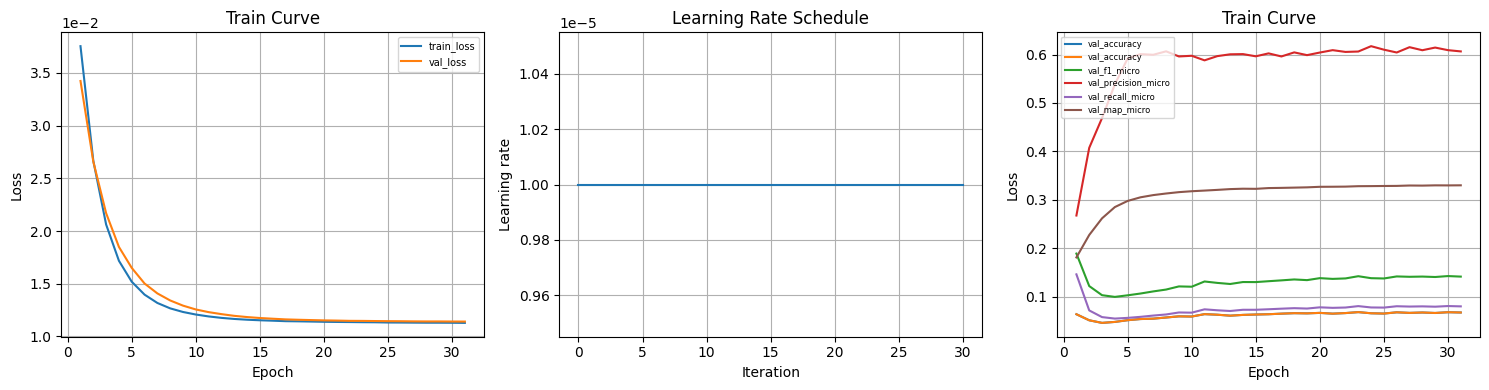

In [113]:
plot_curves(history_cls, task="cls")

In [114]:
inference(model, best_state, task="cls", criterion=criterion)

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 213.44it/s]



               precision    recall  f1-score   support

           0       0.00      0.00      0.00       124
           1       0.00      0.00      0.00       328
           2       0.00      0.00      0.00       329
           3       0.00      0.00      0.00       357
           4       0.64      0.23      0.34       567
           5       0.60      0.01      0.03      1142
           6       0.00      0.00      0.00       285
           7       0.00      0.00      0.00       491
           8       0.51      0.02      0.04      1101
           9       0.57      0.40      0.47      1160
          10       0.00      0.00      0.00        89
          11       0.00      0.00      0.00        38
          12       0.00      0.00      0.00       450
          13       0.25      0.00      0.00      1151
          14       0.00      0.00      0.00        27

   micro avg       0.58      0.08      0.14      7639
   macro avg       0.17      0.04      0.06      7639
weighted avg       0.34 

Test features for confusion: 100%|██████████| 40/40 [00:00<00:00, 258.66it/s]


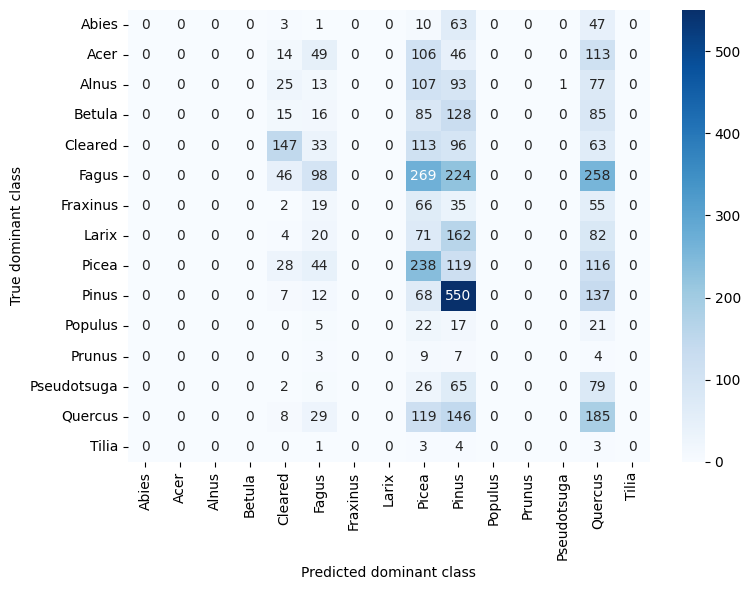

In [64]:
plot_cm(model)

### Regression

In [144]:
configs.update(
    model_type="MLPRegressor",
    max_lr=5e-5,
    weight_decay=1e-5,
    patience=5,
    dropout=0.2,
    epochs=100,
    scheduler=None,
    hidden_dims=(512, 512, 512)
)

print(
    "model_type: ", configs["model_type"],
    "\nmax_lr: ", configs["max_lr"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nscheduler: ", configs["scheduler"],
    "\nhidden_dims: ", configs["hidden_dims"],
)

model = MLPRegressor(in_channels=3, dropout=configs["dropout"], hidden_dims=configs["hidden_dims"]).to(device)
criterion = masked_rmse_loss
optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])
num_epochs = configs["epochs"]
best_val_loss = 99
best_state = None
patience = configs["patience"]
epochs_no_improve = 0
history_reg = {key: [] for key in history_reg}

steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * configs["epochs"]
if configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps,
        eta_min=configs["min_lr"],
    )
elif configs["scheduler"] == "ExponentialLR":
    gamma = (configs["base_lr"] / configs["max_lr"]) ** (1 / total_steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=gamma
    )
else:
    scheduler = None

model_type:  MLPRegressor 
max_lr:  5e-05 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  100 
scheduler:  None 
hidden_dims:  (512, 512, 512)


In [145]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_reg(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        scheduler=scheduler,
    )
    val_metrics = evaluate_reg(model, val_loader, criterion, device)
    print(f"Epoch {epoch}: train {train_loss:.4f}", "val loss: {loss:.4f}, R2: {r2:.4f}".format(**val_metrics), f"lr: {optimizer.param_groups[0]["lr"]}")

    _update_history_reg(history_reg, epoch, train_loss, val_metrics)
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 4)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Patience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
            print("\tEarly stopping triggered after", epoch, "epochs")
            break

Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 199.29it/s]


Epoch 1: train 20.3772 val loss: 18.4377, R2: -5.4289 lr: 5e-05
	Updated best model


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 202.06it/s]


Epoch 2: train 16.7310 val loss: 14.0823, R2: -2.7476 lr: 5e-05
	Updated best model


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 201.68it/s]


...

Epoch 14: train 7.3613 val loss: 7.2574, R2: 0.0215 lr: 5e-05
Patience 3/5 


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 200.60it/s]


Epoch 15: train 7.3520 val loss: 7.2678, R2: 0.0198 lr: 5e-05
Patience 4/5 


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 202.65it/s]


Epoch 16: train 7.3514 val loss: 7.2668, R2: 0.0199 lr: 5e-05
Patience 5/5 
	Early stopping triggered after 16 epochs


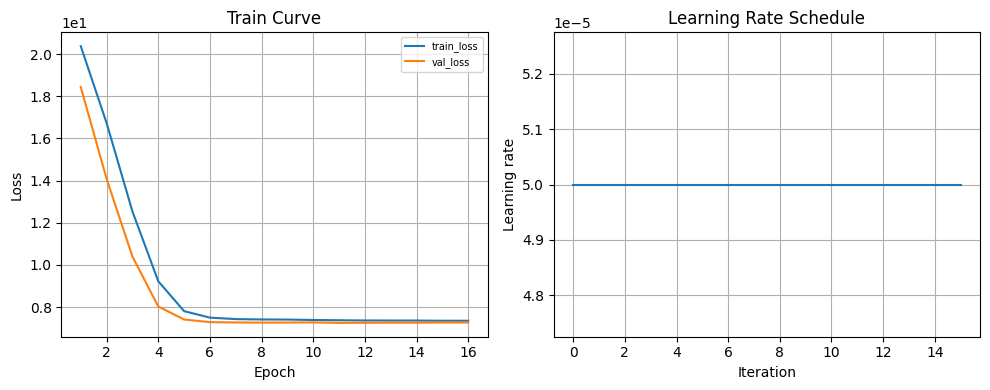

In [146]:
plot_curves(history_reg, task="reg")

In [147]:
inference(model, best_state, task="reg", criterion=criterion)

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 193.76it/s]


train loss:  7.2344 	r2:  0.0522
val loss:  7.2668 	r2:  0.0199
test loss:  7.2709 	r2:  0.0295


Collect reg pairs: 100%|██████████| 40/40 [00:00<00:00, 208.13it/s]


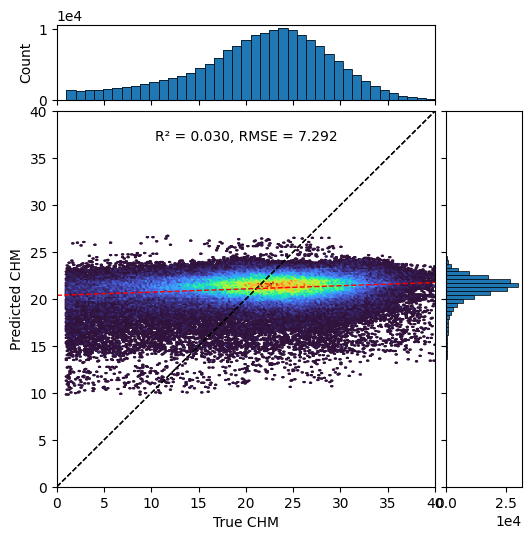

In [148]:
test_true, test_pred = collect_regression_pairs(model)
plot_regression_joint_with_hists(test_true, test_pred, max_value=40)

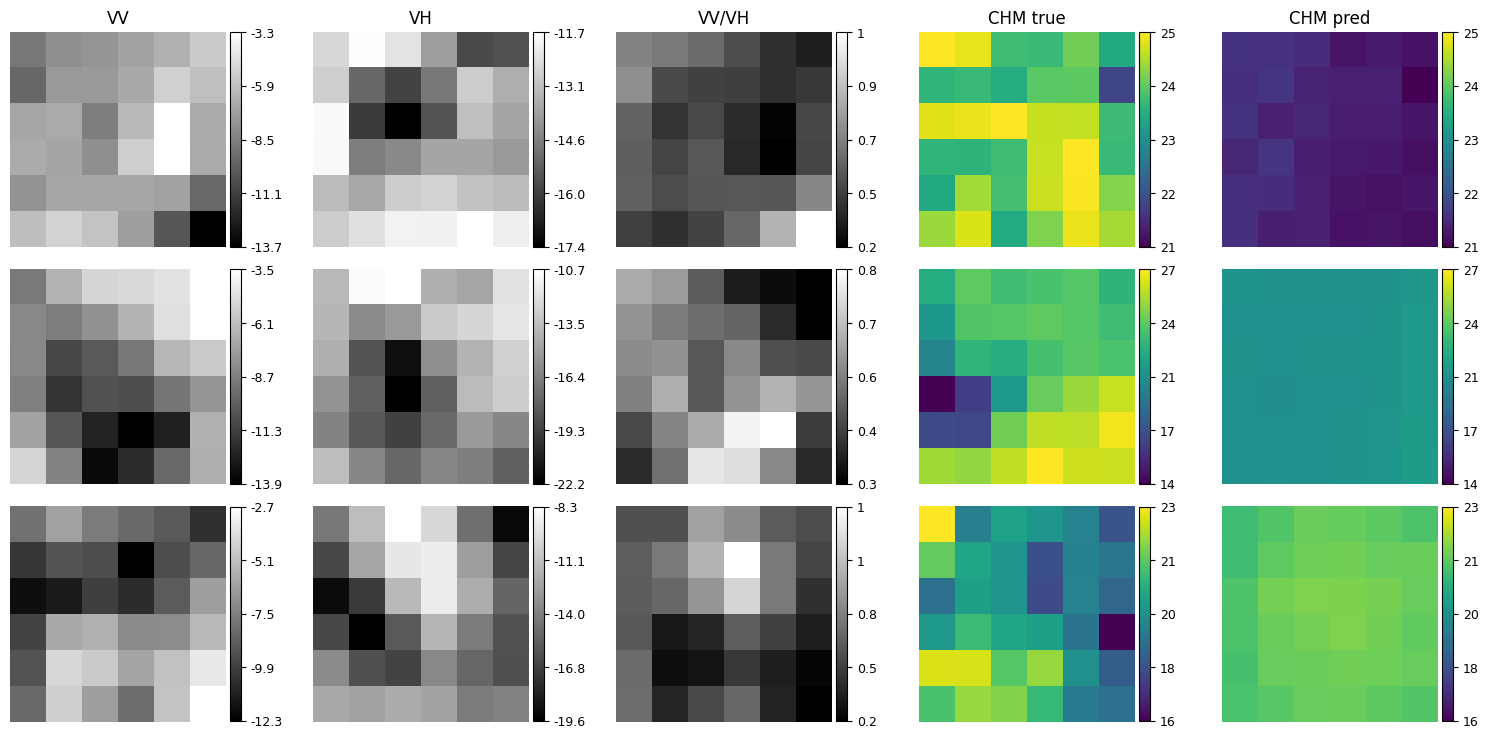

In [149]:
visualize_chm_s1_samples(model, test_ds, start_idx=42, num_samples=3)

Collect reg pairs: 100%|██████████| 315/315 [00:00<00:00, 336.65it/s]


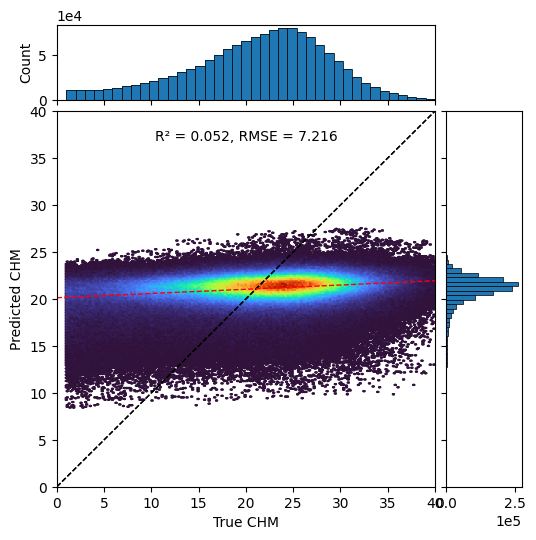

In [150]:
test_true, test_pred = collect_regression_pairs(model, train_loader)
plot_regression_joint_with_hists(test_true, test_pred, max_value=40)

## 2.Baseline - UNet

### Classification

In [115]:
configs.update(
    model_type="UNetClassifier",
    base_channels=256,
    max_lr=1e-5,
    weight_decay=1e-5,
    patience=5,
    dropout=0.2,
    epochs=100
)

print(
    "model_type: ", configs["model_type"],
    "\nbase_channels: ", configs["base_channels"],
    "\nmax_lr: ", configs["max_lr"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
)

model = UNetClassifier(in_channels=3, num_classes=num_classes, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])
scheduler = None
num_epochs = configs["epochs"]
patience = configs["patience"]
epochs_no_improve = 0
best_val_loss = 999
best_state = None
history_cls = {key: [] for key in history_cls}

model_type:  UNetClassifier 
base_channels:  256 
max_lr:  1e-05 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  100


In [116]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_cls(
        model,
        train_loader,
        cls_criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        scheduler=scheduler,
    )
    val_metrics, _, _ = evaluate_cls(model, val_loader, cls_criterion, device)
    print(
        f"Epoch {epoch}: train {train_loss:.4f}, ", "val loss: {loss:.4f}, \n\tweighted F1: {f1_weighted:.4f}, weighted mAP: {map_weighted:.4f}, "
        "accuracy: {accuracy:.4f}".format(**val_metrics)
    )
    _update_history_cls(history_cls, epoch, train_loss, val_metrics)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 4)
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Patience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break

Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 166.75it/s]


Epoch 1: train 0.0244,  val loss: 0.0172, 
	weighted F1: 0.0737, weighted mAP: 0.2676, accuracy: 0.0399
	Updated best model


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 169.58it/s]


Epoch 2: train 0.0151,  val loss: 0.0136, 
	weighted F1: 0.0631, weighted mAP: 0.2819, accuracy: 0.0320
	Updated best model


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 160.79it/s]


...

Epoch 10: train 0.0102,  val loss: 0.0118, 
	weighted F1: 0.1084, weighted mAP: 0.2739, accuracy: 0.0502
Patience 3/5 


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 168.75it/s]


Epoch 11: train 0.0095,  val loss: 0.0121, 
	weighted F1: 0.1378, weighted mAP: 0.2701, accuracy: 0.0782
Patience 4/5 


Eval Cls: 100%|██████████| 40/40 [00:00<00:00, 167.39it/s]


Epoch 12: train 0.0086,  val loss: 0.0124, 
	weighted F1: 0.1695, weighted mAP: 0.2650, accuracy: 0.0885
Patience 5/5 
	Early stopping triggered after 12 epochs


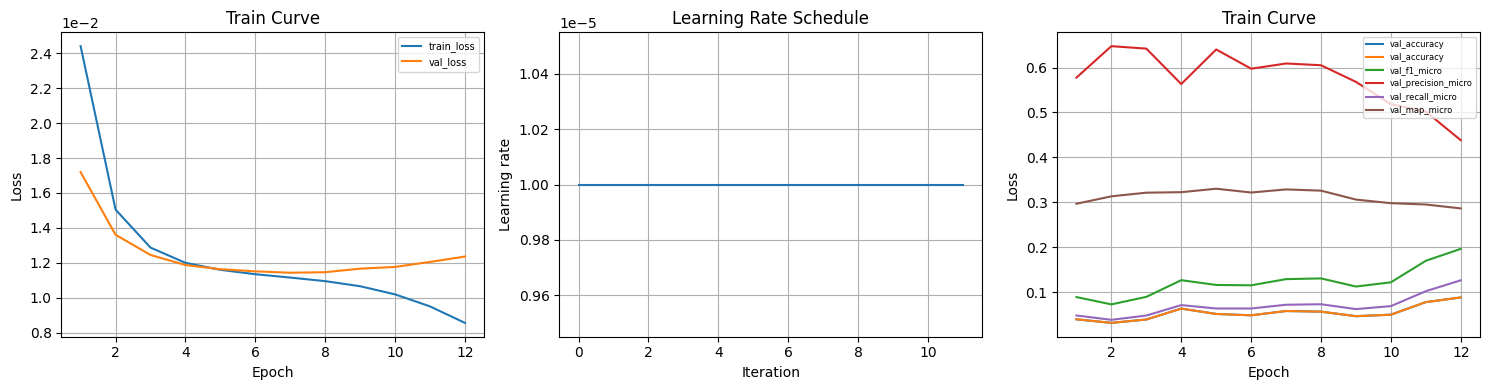

In [118]:
plot_curves(history_cls, task="cls")

Test features for confusion: 100%|██████████| 40/40 [00:00<00:00, 163.09it/s]


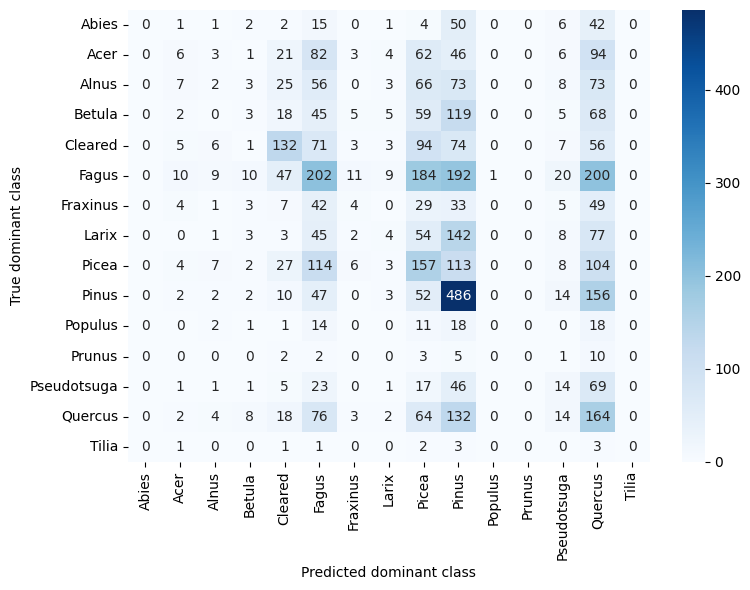

In [119]:
plot_cm(model)

In [120]:
inference(model, best_state, criterion=cls_criterion, task="cls")

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 167.66it/s]



               precision    recall  f1-score   support

           0       0.00      0.00      0.00       124
           1       0.08      0.00      0.01       328
           2       0.12      0.01      0.01       329
           3       0.00      0.00      0.00       357
           4       0.50      0.22      0.30       567
           5       0.35      0.09      0.14      1142
           6       0.33      0.01      0.02       285
           7       0.40      0.00      0.01       491
           8       0.43      0.17      0.25      1101
           9       0.54      0.40      0.46      1160
          10       0.00      0.00      0.00        89
          11       0.00      0.00      0.00        38
          12       0.20      0.01      0.03       450
          13       0.36      0.08      0.13      1151
          14       0.00      0.00      0.00        27

   micro avg       0.45      0.13      0.20      7639
   macro avg       0.22      0.07      0.09      7639
weighted avg       0.35 

### Regression

In [158]:
configs.update(
  model_type="UNetRegressor",
  base_channels=256,
  max_lr=5e-5,
  weight_decay=1e-5,
  patience=5,
  dropout=0.2,
  epochs=100,
  scheduler="None"
)

print(
    "model_type: ", configs["model_type"],
    "\nbase_channels: ", configs["base_channels"],
    "\nmax_lr: ", configs["max_lr"],
    "\nweight_decay: ", configs["weight_decay"],
    "\npatience: ", configs["patience"],
    "\ndropout: ", configs["dropout"],
    "\nepochs: ", configs["epochs"],
    "\nscheduler: ", configs["scheduler"],
)

model = UNetRegressor(3, base_channels=configs["base_channels"], dropout=configs["dropout"]).to(device)
criterion = masked_rmse_loss
optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])
num_epochs = configs["epochs"]
patience = configs["patience"]
total_steps = len(train_loader) * num_epochs
epochs_no_improve = 0
best_val_loss = 999
best_state = None
history_reg = {key: [] for key in history_reg}

if configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps//4,
        eta_min=configs["base_lr"],
    )
elif configs["scheduler"] == "ExponentialLR":
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=0.9999
    )
else:
    scheduler = None

model_type:  UNetRegressor 
base_channels:  256 
max_lr:  5e-05 
weight_decay:  1e-05 
patience:  5 
dropout:  0.2 
epochs:  100 
scheduler:  None


In [159]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_reg(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        device=device,
        epoch=epoch,
        scheduler=scheduler,
    )
    val_metrics = evaluate_reg(model, val_loader, criterion, device)
    print(f"Epoch {epoch}: train {train_loss:.4f}", "val loss: {loss:.4f}, R2: {r2:.4f}".format(**val_metrics), f"lr: {optimizer.param_groups[0]["lr"]}")
    _update_history_reg(history_reg, epoch, train_loss, val_metrics)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = round(val_metrics["loss"], 5)
        best_state = model.state_dict()
        history_reg.update(best_epoch=epoch)
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"\tPatience {epochs_no_improve}/{patience} ")
    if epochs_no_improve >= patience:
        print("\tEarly stopping triggered after", epoch, "epochs")
        break
    if optimizer.param_groups[0]["lr"] < configs["base_lr"]+1e-8:
        scheduler = None

Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 132.28it/s]


Epoch 1: train 19.9114 val loss: 18.8858, R2: -5.7267 lr: 5e-05
	Updated best model


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 137.37it/s]


Epoch 2: train 18.7296 val loss: 18.3937, R2: -5.3751 lr: 5e-05
	Updated best model


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 133.46it/s]


...

Epoch 24: train 7.2603 val loss: 7.2040, R2: 0.0364 lr: 5e-05
	Patience 3/5 


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 136.47it/s]


Epoch 25: train 7.2574 val loss: 7.2196, R2: 0.0326 lr: 5e-05
	Patience 4/5 


Eval Reg: 100%|██████████| 40/40 [00:00<00:00, 140.48it/s]

Epoch 26: train 7.2575 val loss: 7.2057, R2: 0.0361 lr: 5e-05
	Patience 5/5 
	Early stopping triggered after 26 epochs


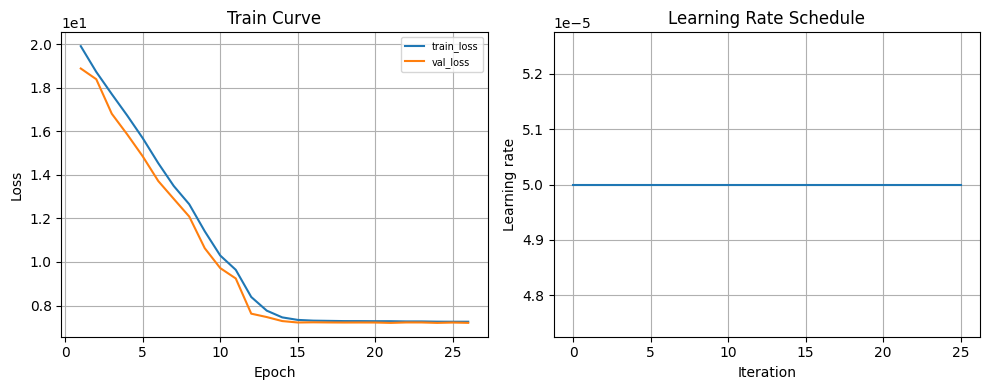

In [160]:
plot_curves(history_reg, task='reg')

In [161]:
inference(model, best_state, criterion=masked_rmse_loss, task="reg")

Test Eval: 100%|██████████| 40/40 [00:00<00:00, 138.21it/s]


train loss:  7.2418 	r2:  0.0505
val loss:  7.2057 	r2:  0.0361
test loss:  7.2230 	r2:  0.0419


Collect reg pairs: 100%|██████████| 40/40 [00:00<00:00, 141.22it/s]


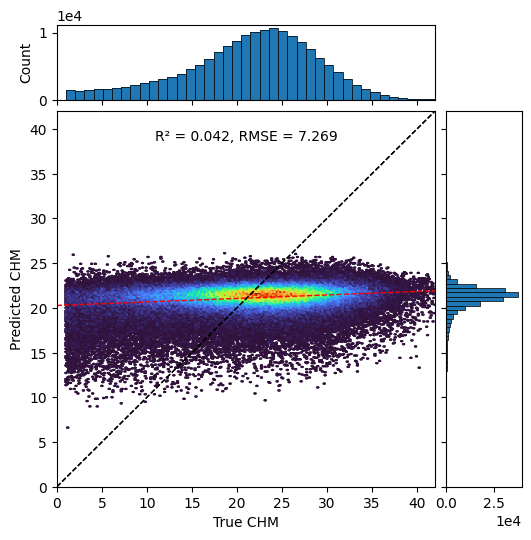

In [162]:
test_true, test_pred = collect_regression_pairs(model, test_loader)
plot_regression_joint_with_hists(test_true, test_pred, max_value=42)

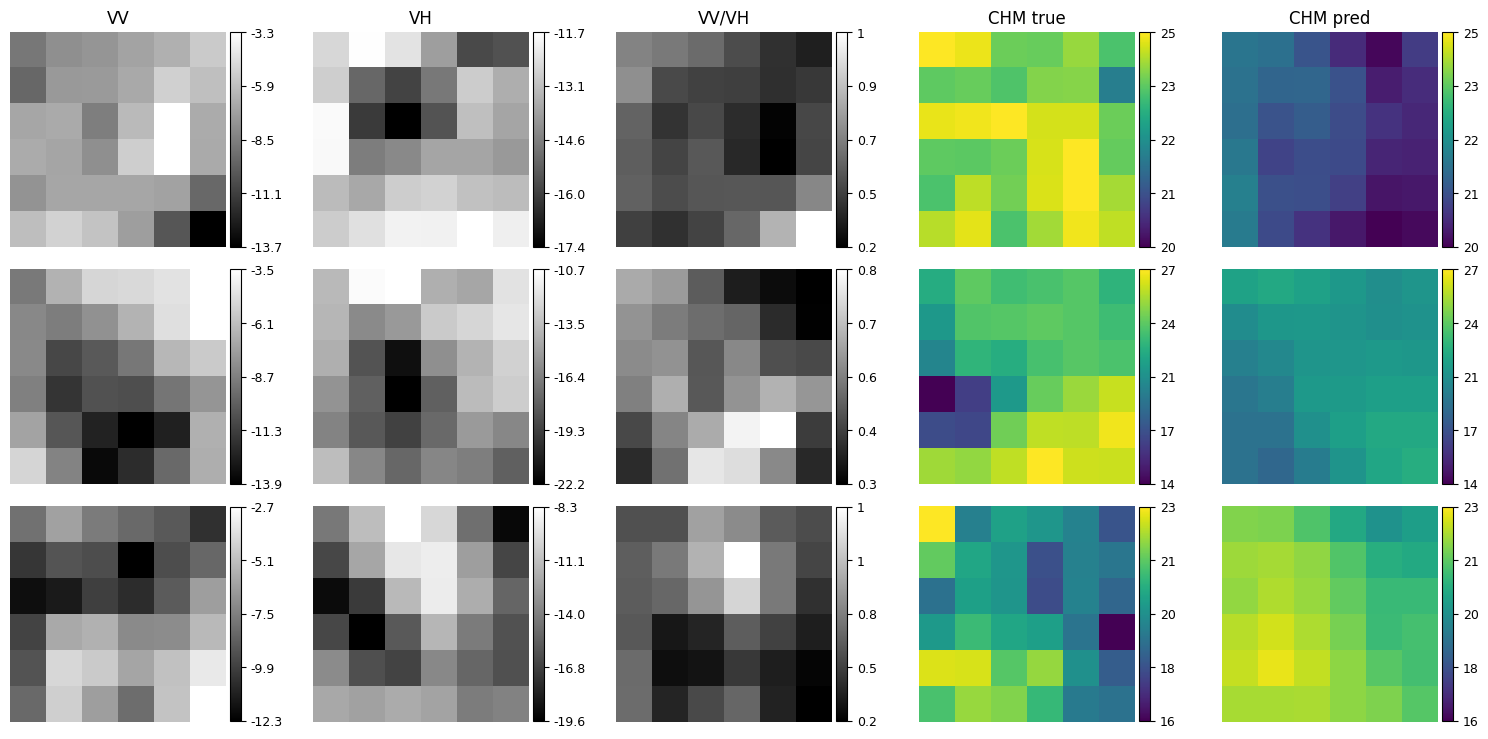

In [163]:
visualize_chm_s1_samples(model, test_ds, start_idx=42, num_samples=3)

Collect reg pairs: 100%|██████████| 315/315 [00:01<00:00, 185.88it/s]


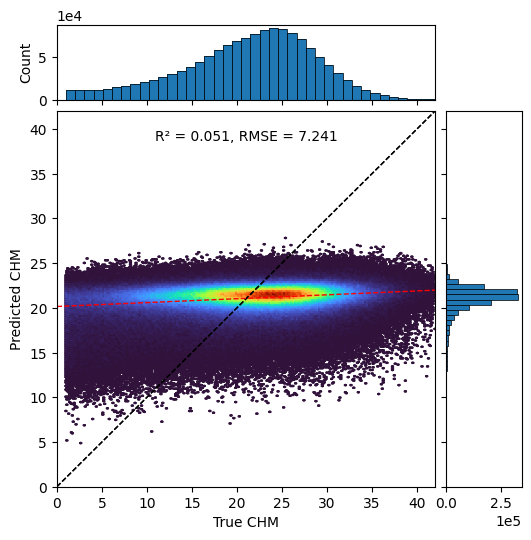

In [164]:
test_true, test_pred = collect_regression_pairs(model, train_loader)
plot_regression_joint_with_hists(test_true, test_pred, max_value=42)